In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

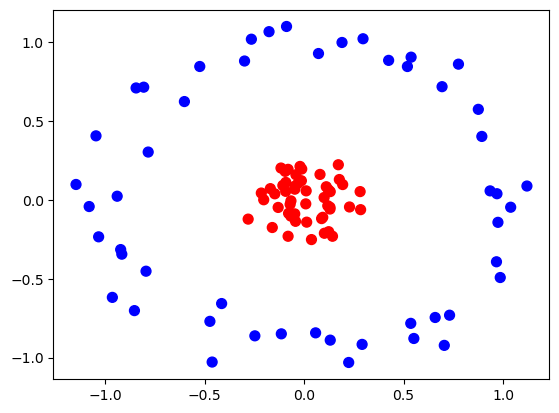

In [5]:
from sklearn.datasets import make_circles

X,y = make_circles(100, factor=0.1, noise = 0.1)

plt.scatter(X[:,0], X[:,1], c=y , s=50, cmap='bwr')


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)


In [7]:
classifier = SVC(kernel = "linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6333333333333333

In [12]:
zero_one_color=ListedColormap(['blue','red'])
def plot_decision_boundary(X,y,clf):
    X_set, y_set = X, y
    x1, x2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, 
                                    stop = X_set[:,0].max() + 1,
                                    step = 0.01),
                        np.arange(start=X_set[:,1].min() -1,
                                    stop = X_set[:,1].max() + 1,
                                    step = 0.01)
                                   )
    
    plt.contourf(x1, x2, clf.predict(np.array([x1.ravel(),x2.ravel()]).T).reshape(x1.shape),
                 alpha = 0.75,
                 cmap = zero_one_color)
    
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())

    for i,j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set ==j , 0], X_set[y_set ==j, 1],
                    c=(zero_one_color)(i), label = j)
    plt.title("SVM Decision Boundry")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.legend()
    return plt.show()



C:\Users\DSingh\AppData\Local\Temp\ipykernel_5320\3114160671.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set ==j , 0], X_set[y_set ==j, 1],


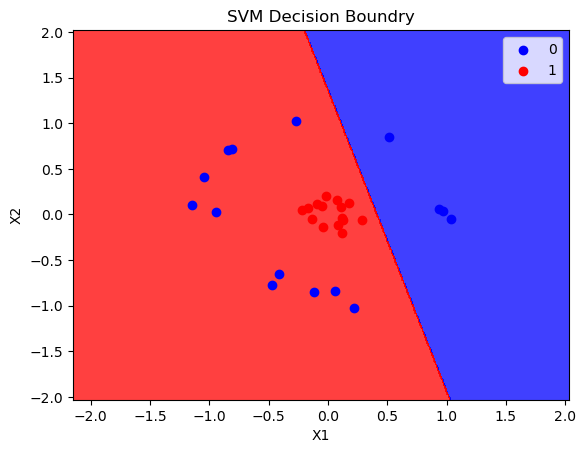

In [13]:
plot_decision_boundary(X_test, y_test, classifier)

In [14]:
def plot_3d_plot(X,y):
    r=np.exp(-(X**2).sum(1))
    ax=plt.subplot(projection='3d')
    ax.scatter3D(X[:,0], X[:,1], r, c=y , s=100, cmap='bwr')
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Z")
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='Z'>

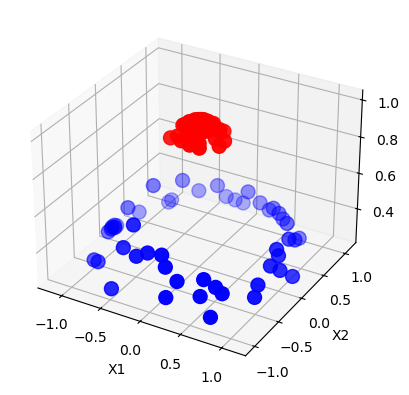

In [15]:
plot_3d_plot(X,y)

In [16]:
SVC?

Init signature:
SVC(
    *,
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=None,
)
Docstring:     
C-Support Vector Classification.

The implementation is based on libsvm. The fit time scales at least
quadratically with the number of samples and may be impractical
beyond tens of thousands of samples. For large datasets
consider using :class:`~sklearn.svm.LinearSVC` or
:class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
:class:`~sklearn.kernel_approximation.Nystroem` transformer or
other :ref:`kernel_approximation`.

The multiclass support is handled according to a one-vs-one scheme.

For details on the precise mathematical formulation of the provided
kernel functions and how `gamma`, `coef0` and `degree` affect each
other, see the

In [17]:
rbf_classifier = SVC(kernel = "rbf")
rbf_classifier.fit(X_train, y_train)
y_pred_rbf = rbf_classifier.predict(X_test)

In [18]:
accuracy_score(y_test, y_pred_rbf)

1.0

C:\Users\DSingh\AppData\Local\Temp\ipykernel_5320\3114160671.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set ==j , 0], X_set[y_set ==j, 1],


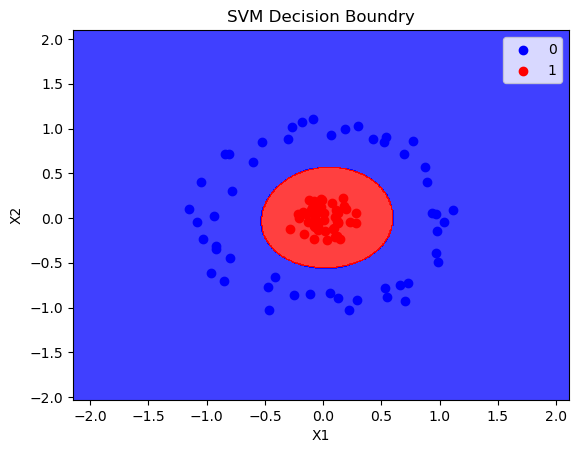

In [19]:
plot_decision_boundary(X,y,rbf_classifier)

0.5333333333333333


C:\Users\DSingh\AppData\Local\Temp\ipykernel_5320\3114160671.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set ==j , 0], X_set[y_set ==j, 1],


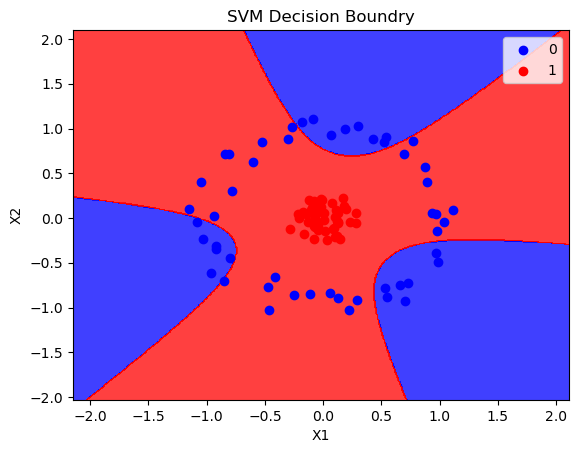

In [20]:
poly_classifier = SVC(kernel = "poly")
poly_classifier.fit(X_train, y_train)
y_pred_poly = poly_classifier.predict(X_test)

print(accuracy_score(y_test, y_pred_poly))

plot_decision_boundary(X,y,poly_classifier)